### MLP Model made using PyTorch
Relevant Statistics: Made via MLP with 7 layers (optimized via Optuna)

| Category          | Accuracy | Precision | Recall | F1 Score | ROC AUC | Positive Samples | Negative Samples |
|-------------------|-----------|------------|--------|-----------|----------|------------------|------------------|
| any               | 0.8384    | 0.8047     | 0.7992 | 0.8020    | 0.9013   | 1320.0           | 1905.0           |
| epidural          | 0.7247    | 0.0333     | 0.6522 | 0.0633    | 0.7781   | 46.0             | 3179.0           |
| intraparenchymal  | 0.7392    | 0.4846     | 0.8038 | 0.6046    | 0.8173   | 800.0            | 2425.0           |
| intraventricular  | 0.7002    | 0.3460     | 0.8128 | 0.4854    | 0.7849   | 561.0            | 2664.0           |
| subarachnoid      | 0.7057    | 0.3719     | 0.7990 | 0.5075    | 0.7924   | 612.0            | 2613.0           |
| subdural          | 0.7033    | 0.3584     | 0.8082 | 0.4966    | 0.7896   | 584.0            | 2641.0           |


AUC Average: 0.8106

# Hemorrhage Detection MLP Model with Hyperparameter Optimization

This notebook implements a Multi-Layer Perceptron (MLP) for hemorrhage detection with automated hyperparameter optimization. The process follows these steps:

1. Setup and Data Preparation
2. Model Definition and Hyperparameter Optimization
3. Training the Best Model
4. Model Evaluation and Visualization
5. Save Model and Results

## 1. Setup and Data Preparation

In [1]:
# Import required libraries (PyTorch version)
import torch

print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device")

# Check if CUDA is available
print(torch.cuda.is_available()) # True if CUDA is available

# Get the number of GPUs available
print(torch.cuda.device_count()) # Number of GPUs

# Get the name of the current GPU
print(torch.cuda.get_device_name(0)) # Name of GPU, e.g., 'GeForce GTX 950M'

PyTorch version: 2.7.1+cu128
CUDA version: 12.8
CUDA available: True
CUDA device name: NVIDIA GeForce RTX 5060 Laptop GPU
True
1
NVIDIA GeForce RTX 5060 Laptop GPU


In [ ]:
# Import required libraries (CUDA version)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

# Import Optuna for hyperparameter optimization
!pip install optuna
import optuna
from optuna.trial import TrialState

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 25.2 MB/s eta 0:00:00


In [ ]:
# Load the datasets into pandas DataFrames
df_hemo = pd.read_csv('/content/Rsna_ICH_Hemm.csv')
df_control = pd.read_csv('/content/Rsna_ICH_Control.csv')

# Combine the datasets
df = pd.concat([df_hemo, df_control], ignore_index=True)

# Convert the 'embedding' column from string to a list
df['embedding'] = df['embedding'].apply(eval)

# Define the target columns in the proper order
target_columns = ['any', 'epidural', 'intraparenchymal', 'intraventricular', 'subarachnoid', 'subdural']

In [ ]:
# Load the embeddings and target values
X = np.array(df['embedding'].tolist(), dtype=np.float32)
y = df[target_columns].values.astype(np.float32)

# Split the data with 80 percent for training and 20 percent for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
# Define an Early Stopping class

class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0

    def __call__(self, val_loss):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

### Calculate Class Weights for Imbalanced Data

## 2. Model Definition and Hyperparameter Optimization

In [ ]:
# Create custom weights to handle class imbalance
# Calculate positive weights for each class
pos_weights = []
for i in range(len(target_columns)):
    num_pos = np.sum(y_train[:, i])
    num_neg = y_train.shape[0] - num_pos
    # Avoid division by zero
    weight = num_neg / (num_pos + 1e-6)
    pos_weights.append(weight)
pos_weights = torch.tensor(pos_weights, dtype=torch.float32)

# Move pos_weights to the same device as the model will be on
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weights = pos_weights.to(device)

# Use pos_weight in BCEWithLogitsLoss
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

In [ ]:
# Define the dynamic MLP model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class HemorrhageMLP(nn.Module):
    def __init__(self, input_size, output_size, layer_sizes, dropout_rates):
        super(HemorrhageMLP, self).__init__()

        # Create a list to hold all layers
        layers = []
        prev_size = input_size

        # Add layers dynamically based on the provided sizes
        for i, size in enumerate(layer_sizes):
            layers.append(nn.Linear(prev_size, size))
            layers.append(nn.BatchNorm1d(size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rates[i]))
            prev_size = size

        # Add final output layer
        layers.append(nn.Linear(prev_size, output_size))

        # Create sequential model
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

def objective(trial):
    # Number of layers (between 3 and 7)
    n_layers = trial.suggest_int("n_layers", 3, 7)

    # Layer sizes (decreasing from input to output)
    layer_sizes = []
    prev_size = X_train_tensor.shape[1]  # Input size
    for i in range(n_layers):
        layer_sizes.append(trial.suggest_int(f"n_units_l{i}",
                                           int(prev_size/2),  # At least half the previous size
                                           min(2048, prev_size*2)))  # At most double the previous size
        prev_size = layer_sizes[-1]

    # Dropout rates for each layer
    dropout_rates = [trial.suggest_float(f"dropout_l{i}", 0.1, 0.5) for i in range(n_layers)]

    # Learning rate
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)

    # Create model
    model = HemorrhageMLP(
        input_size=X_train_tensor.shape[1],
        output_size=len(target_columns),
        layer_sizes=layer_sizes,
        dropout_rates=dropout_rates
    ).to(device)

    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Training loop
    best_val_loss = float('inf')
    patience = 5
    patience_counter = 0

    for epoch in range(50):  # Maximum 50 epochs
        model.train()
        train_loss = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            output = model(xb)
            loss = criterion(output, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item() * xb.size(0)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                output = model(xb)
                loss = criterion(output, yb)
                val_loss += loss.item() * xb.size(0)

        val_loss /= len(test_loader.dataset)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    return best_val_loss

In [ ]:
# Define the best parameters from the provided Optuna trial
best_n_layers = 7
best_layer_sizes = [807, 467, 258, 180, 126, 85, 43]
best_dropout_rates = [0.19165948584259396, 0.2520683029657358, 0.3976052695516048, 0.44077739067431176, 0.4108096582517331, 0.41117403178491185, 0.17531093031749775]
best_lr = 0.00018774581889987335

# Create the best model instance
# Ensure input_size and output_size are correctly defined based on your data
input_size = X_train_tensor.shape[1]  # Assuming X_train_tensor is available
output_size = len(target_columns) # Assuming target_columns is available

best_model = HemorrhageMLP(
    input_size=input_size,
    output_size=output_size,
    layer_sizes=best_layer_sizes,
    dropout_rates=best_dropout_rates
).to(device) # Assuming 'device' is defined (cuda or cpu)

print("Best model recreated successfully.")
print(f"Number of layers: {best_n_layers}")
print(f"Learning rate: {best_lr}")
print("Layer sizes:", best_layer_sizes)
print("Dropout rates:", best_dropout_rates)

Best model recreated successfully.
Number of layers: 7
Learning rate: 0.00018774581889987335
Layer sizes: [807, 467, 258, 180, 126, 85, 43]
Dropout rates: [0.19165948584259396, 0.2520683029657358, 0.3976052695516048, 0.44077739067431176, 0.4108096582517331, 0.41117403178491185, 0.17531093031749775]


In [ ]:
# Create a study object and run optimization
study = optuna.create_study(direction="minimize")

# Run the optimization
print("Starting hyperparameter optimization...")
study.optimize(objective, n_trials=50)  # Try 50 different configurations

# Get the best parameters
best_trial = study.best_trial
print("Best trial:")
print("  Value: ", best_trial.value)
print("  Params: ")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

# Create the best model
best_n_layers = best_trial.params["n_layers"]
best_layer_sizes = [best_trial.params[f"n_units_l{i}"] for i in range(best_n_layers)]
best_dropout_rates = [best_trial.params[f"dropout_l{i}"] for i in range(best_n_layers)]

best_model = HemorrhageMLP(
    input_size=X_train_tensor.shape[1],
    output_size=len(target_columns),
    layer_sizes=best_layer_sizes,
    dropout_rates=best_dropout_rates
).to(device)

[I 2025-10-30 07:37:34,995] A new study created in memory with name: no-name-05741616-effd-43fd-9c0c-21bcef75d7d8


Starting hyperparameter optimization...


[I 2025-10-30 07:38:03,066] Trial 0 finished with value: 0.8442878581017487 and parameters: {'n_layers': 6, 'n_units_l0': 1291, 'n_units_l1': 1675, 'n_units_l2': 1120, 'n_units_l3': 1791, 'n_units_l4': 918, 'n_units_l5': 1184, 'dropout_l0': 0.1896474286737258, 'dropout_l1': 0.1857368080380531, 'dropout_l2': 0.13057294252889357, 'dropout_l3': 0.22178564813137838, 'dropout_l4': 0.4542308560835243, 'dropout_l5': 0.24966796366059985, 'lr': 0.00018465700425120515}. Best is trial 0 with value: 0.8442878581017487.
[I 2025-10-30 07:38:24,126] Trial 1 finished with value: 0.8409895105694616 and parameters: {'n_layers': 3, 'n_units_l0': 1928, 'n_units_l1': 1567, 'n_units_l2': 1159, 'dropout_l0': 0.15519315050261495, 'dropout_l1': 0.27020069744023184, 'dropout_l2': 0.15035563094655477, 'lr': 1.1828320000784227e-05}. Best is trial 1 with value: 0.8409895105694616.
[I 2025-10-30 07:38:52,974] Trial 2 finished with value: 0.8307880023653194 and parameters: {'n_layers': 7, 'n_units_l0': 882, 'n_units

## 3. Training the Best Model

In [ ]:
# Train the best model

optimizer = optim.Adam(best_model.parameters(), lr= 0.00018774581889987335)
early_stopper = EarlyStopping(patience=5)

# Train the model using 50 epochs with early stopping
num_epochs = 50
for epoch in range(num_epochs):
    best_model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        output = best_model(xb)
        loss = criterion(output, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(best_model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    # Validation
    best_model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            output = best_model(xb)
            loss = criterion(output, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(test_loader.dataset)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    early_stopper(val_loss)
    if early_stopper.early_stop:
        print("Early stopping triggered.")
        break

Epoch 1: Train Loss=1.0493, Val Loss=0.9098
Epoch 2: Train Loss=0.9405, Val Loss=0.8626
Epoch 3: Train Loss=0.9150, Val Loss=0.8522
Epoch 4: Train Loss=0.9079, Val Loss=0.8392
Epoch 5: Train Loss=0.9004, Val Loss=0.8380
Epoch 6: Train Loss=0.8982, Val Loss=0.8568
Epoch 7: Train Loss=0.8999, Val Loss=0.8276
Epoch 8: Train Loss=0.8860, Val Loss=0.8365
Epoch 9: Train Loss=0.8819, Val Loss=0.8239
Epoch 10: Train Loss=0.8811, Val Loss=0.8339
Epoch 11: Train Loss=0.8622, Val Loss=0.8262
Epoch 12: Train Loss=0.8720, Val Loss=0.8205
Epoch 13: Train Loss=0.8712, Val Loss=0.8232
Epoch 14: Train Loss=0.8596, Val Loss=0.8173
Epoch 15: Train Loss=0.8620, Val Loss=0.8163
Epoch 16: Train Loss=0.8487, Val Loss=0.8231
Epoch 17: Train Loss=0.8518, Val Loss=0.8288
Epoch 18: Train Loss=0.8567, Val Loss=0.8248
Epoch 19: Train Loss=0.8572, Val Loss=0.8248
Epoch 20: Train Loss=0.8397, Val Loss=0.8142
Epoch 21: Train Loss=0.8435, Val Loss=0.8207
Epoch 22: Train Loss=0.8326, Val Loss=0.8167
Epoch 23: Train Los

In [ ]:
from sklearn.metrics import accuracy_score

best_model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        output = best_model(xb)
        preds = (torch.sigmoid(output) > 0.5).cpu().numpy()
        y_true.append(yb.numpy())
        y_pred.append(preds)
y_true = np.vstack(y_true)
y_pred = np.vstack(y_pred)
print("Test accuracy (any class):", accuracy_score(y_true[:,0], y_pred[:,0]))

Test accuracy (any class): 0.8384496124031008


## 4. Model Evaluation and Visualization

           Category  Accuracy
0               any  0.838450
1          epidural  0.724651
2  intraparenchymal  0.739225
3  intraventricular  0.700155
4      subarachnoid  0.705736
5          subdural  0.703256


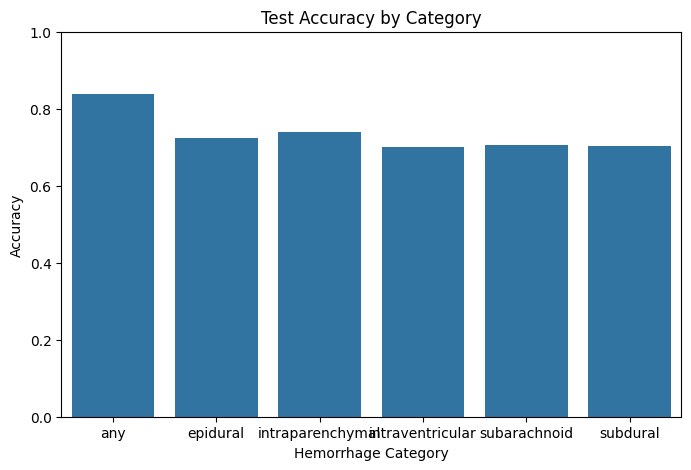

In [ ]:
# Calculate accuracy for each category
accuracies = []
for i, col in enumerate(target_columns):
    acc = accuracy_score(y_true[:, i], y_pred[:, i])
    accuracies.append(acc)

# Prepare DataFrame for seaborn
acc_df = pd.DataFrame({
    'Category': target_columns,
    'Accuracy': accuracies
})

# Display statistics
print(acc_df)

# Plot using seaborn
plt.figure(figsize=(8, 5))
sns.barplot(x='Category', y='Accuracy', data=acc_df)
plt.ylim(0, 1)
plt.title('Test Accuracy by Category')
plt.ylabel('Accuracy')
plt.xlabel('Hemorrhage Category')
plt.show()

           Category  Accuracy  Precision    Recall        F1
0               any  0.838450   0.804729  0.799242  0.801976
1          epidural  0.724651   0.033259  0.652174  0.063291
2  intraparenchymal  0.739225   0.484552  0.803750  0.604607
3  intraventricular  0.700155   0.345979  0.812834  0.485365
4      subarachnoid  0.705736   0.371863  0.799020  0.507525
5          subdural  0.703256   0.358390  0.808219  0.496581


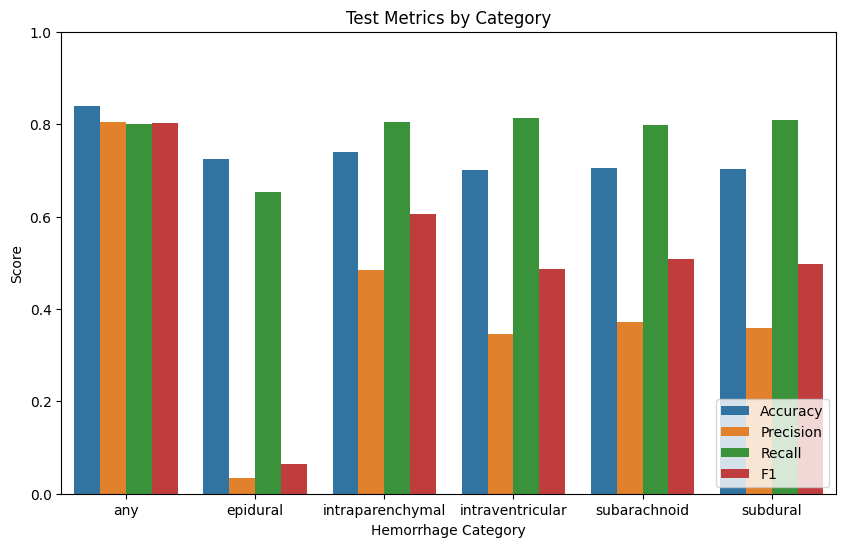

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics for each category
metrics = []
for i, col in enumerate(target_columns):
    acc = accuracy_score(y_true[:, i], y_pred[:, i])
    prec = precision_score(y_true[:, i], y_pred[:, i], zero_division=0)
    rec = recall_score(y_true[:, i], y_pred[:, i], zero_division=0)
    f1 = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)
    metrics.append({'Category': col, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})

# Prepare DataFrame for seaborn
import pandas as pd
metrics_df = pd.DataFrame(metrics)

# Display statistics
print(metrics_df)

# Plot using seaborn
plt.figure(figsize=(10, 6))
metrics_melted = metrics_df.melt(id_vars='Category', value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
                                 var_name='Metric', value_name='Score')
sns.barplot(x='Category', y='Score', hue='Metric', data=metrics_melted)
plt.ylim(0, 1)
plt.title('Test Metrics by Category')
plt.ylabel('Score')
plt.xlabel('Hemorrhage Category')
plt.legend(loc='lower right')
plt.show()

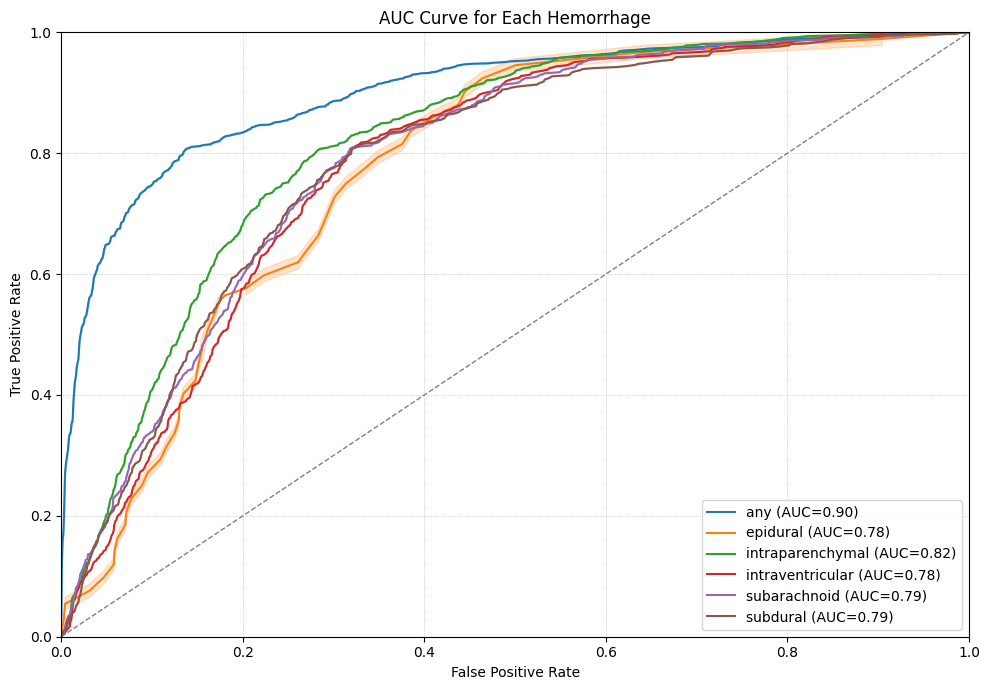

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Get predicted probabilities
best_model.eval()
y_score = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        output = best_model(xb)
        # Apply sigmoid to get probabilities for ROC curve
        probabilities = torch.sigmoid(output).cpu().numpy()
        y_score.append(probabilities)
y_score = np.vstack(y_score)


plt.figure(figsize=(10, 7))
colors = sns.color_palette("tab10", len(target_columns))

for i, col in enumerate(target_columns):
    # Get true labels and predicted probabilities for each category
    fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
    auc = roc_auc_score(y_true[:, i], y_score[:, i]) # Use y_score for AUC
    sns.lineplot(x=fpr, y=tpr, color=colors[i], label=f"{col} (AUC={auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve for Each Hemorrhage')
plt.legend(loc='lower right')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.grid(True, ls=':', lw=0.5)  # Add grid lines
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Calculate percentage of 1s and 0s for each category in the test set
category_stats = []
for i, col in enumerate(target_columns):
    total = len(y_true)
    ones = np.sum(y_true[:, i])
    zeros = total - ones
    percent_ones = ones / total * 100
    percent_zeros = zeros / total * 100
    category_stats.append({
        'Category': col,
        'Percent 1': percent_ones,
        'Percent 0': percent_zeros,
        'Count 1': int(ones),
        'Count 0': int(zeros),
        'Total': total
    })

stats_df = pd.DataFrame(category_stats)
print(stats_df)

           Category  Percent 1  Percent 0  Count 1  Count 0  Total
0               any  40.930233  59.069763     1320     1905   3225
1          epidural   1.426357  98.573647       46     3179   3225
2  intraparenchymal  24.806202  75.193802      800     2425   3225
3  intraventricular  17.395350  82.604652      561     2664   3225
4      subarachnoid  18.976744  81.023254      612     2613   3225
5          subdural  18.108528  81.891472      584     2641   3225


In [ ]:
# Save the best model and hyperparameters
import json
import os

# Get the current directory path and create model_saves directory
current_dir = os.path.dirname(os.path.abspath('__file__'))
save_dir = os.path.join(current_dir, 'model_saves')

# Create a directory for the model if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Create full paths for saving
model_path = os.path.join(save_dir, 'best_hemorrhage_model.pth')
params_path = os.path.join(save_dir, 'model_hyperparameters.json')

# Save the model state
torch.save(best_model.state_dict(), model_path)

# Save hyperparameters
hyperparams = {
    'n_layers': best_n_layers,
    'layer_sizes': best_layer_sizes,
    'dropout_rates': best_dropout_rates,
    'learning_rate':  0.00018774581889,
    'input_size': X_train_tensor.shape[1],
    'output_size': len(target_columns)
}

with open(params_path, 'w') as f:
    json.dump(hyperparams, f, indent=4)

print(f"Model saved to: {model_path}")
print(f"Parameters saved to: {params_path}")

Model saved to: /content/model_saves/best_hemorrhage_model.pth
Parameters saved to: /content/model_saves/model_hyperparameters.json


## 5. Save Model and Results

# Best Model Architecture and Performance Summary

Below is a comprehensive summary of the best performing model configuration and its performance metrics.

Best Model Architecture:
--------------------------------------------------
Number of layers: 7

Layer sizes:
Layer 1: 807 neurons (dropout: 0.192)
Layer 2: 467 neurons (dropout: 0.252)
Layer 3: 258 neurons (dropout: 0.398)
Layer 4: 180 neurons (dropout: 0.441)
Layer 5: 126 neurons (dropout: 0.411)
Layer 6: 85 neurons (dropout: 0.411)
Layer 7: 43 neurons (dropout: 0.175)

Learning rate: 0.000187
--------------------------------------------------

Detailed Performance Metrics:
        Category  Accuracy  Precision  Recall  F1 Score  ROC AUC  Positive Samples  Negative Samples
             any    0.8384     0.8047  0.7992    0.8020   0.9013            1320.0            1905.0
        epidural    0.7247     0.0333  0.6522    0.0633   0.7781              46.0            3179.0
intraparenchymal    0.7392     0.4846  0.8038    0.6046   0.8173             800.0            2425.0
intraventricular    0.7002     0.3460  0.8128    0.4854   0.7849             561.0            2664.0
    subarachno

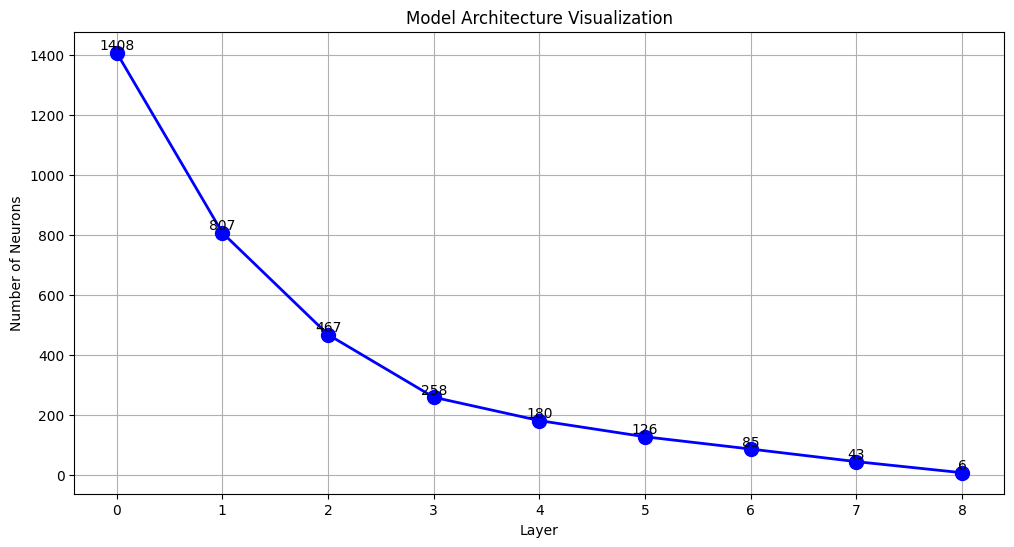

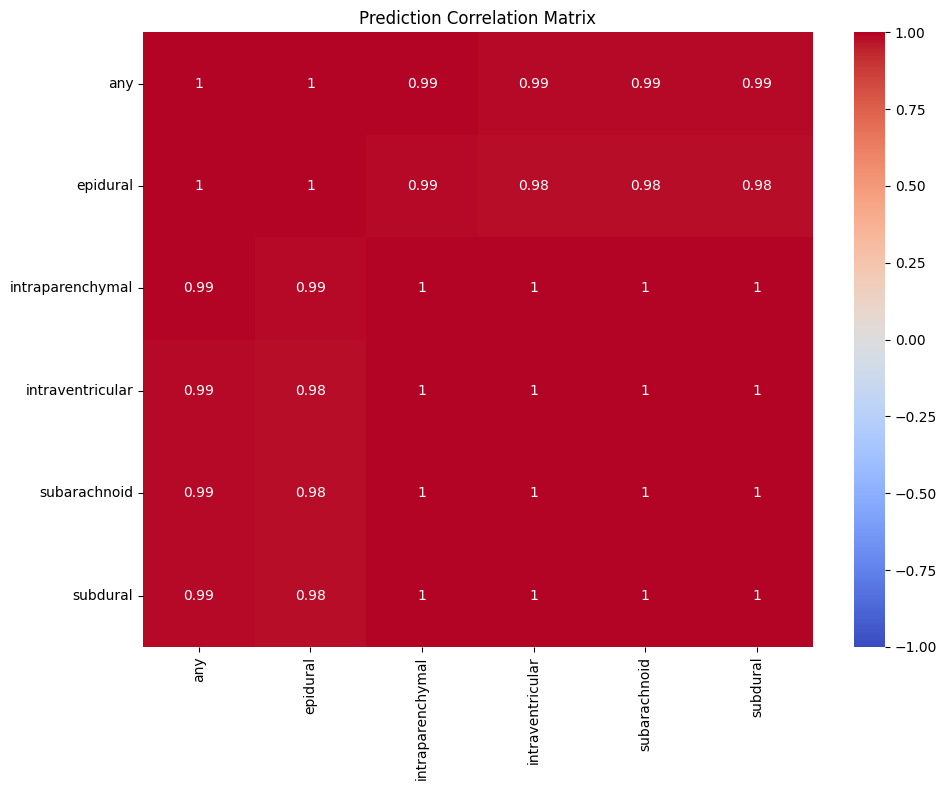

In [ ]:
# Display model architecture details
print("Best Model Architecture:")
print("-" * 50)
print(f"Number of layers: {best_n_layers}")
print("\nLayer sizes:")
for i, size in enumerate(best_layer_sizes):
    print(f"Layer {i+1}: {size} neurons (dropout: {best_dropout_rates[i]:.3f})")
print(f"\nLearning rate: { 0.000187}")
print("-" * 50)

# Calculate and display performance metrics for each category
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

metrics_dict = {
    'Category': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1 Score': [],
    'ROC AUC': [],
    'Positive Samples': [],
    'Negative Samples': []
}

for i, category in enumerate(target_columns):
    metrics_dict['Category'].append(category)
    metrics_dict['Accuracy'].append(accuracy_score(y_true[:, i], y_pred[:, i]))
    metrics_dict['Precision'].append(precision_score(y_true[:, i], y_pred[:, i], zero_division=0))
    metrics_dict['Recall'].append(recall_score(y_true[:, i], y_pred[:, i], zero_division=0))
    metrics_dict['F1 Score'].append(f1_score(y_true[:, i], y_pred[:, i], zero_division=0))
    metrics_dict['ROC AUC'].append(roc_auc_score(y_true[:, i], y_score[:, i]))
    metrics_dict['Positive Samples'].append(np.sum(y_true[:, i]))
    metrics_dict['Negative Samples'].append(len(y_true[:, i]) - np.sum(y_true[:, i]))

metrics_df = pd.DataFrame(metrics_dict)
print("\nDetailed Performance Metrics:")
print(metrics_df.round(4).to_string(index=False))

# Create visualization of the model architecture
plt.figure(figsize=(12, 6))
layer_sizes = [X_train_tensor.shape[1]] + best_layer_sizes + [len(target_columns)]
plt.plot(range(len(layer_sizes)), layer_sizes, 'bo-', linewidth=2, markersize=10)
plt.title('Model Architecture Visualization')
plt.xlabel('Layer')
plt.ylabel('Number of Neurons')
plt.grid(True)
for i, size in enumerate(layer_sizes):
    plt.text(i, size, str(size), ha='center', va='bottom')
plt.show()

# Plot correlation matrix of predictions
plt.figure(figsize=(10, 8))
correlation_matrix = np.corrcoef(y_score.T)
sns.heatmap(correlation_matrix,
            xticklabels=target_columns,
            yticklabels=target_columns,
            annot=True,
            cmap='coolwarm',
            center=0,
            vmin=-1,
            vmax=1)
plt.title('Prediction Correlation Matrix')
plt.tight_layout()
plt.show()